In [1]:
import pandas as pd
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

from bluemath_tk.datamining import PCA
from bluemath_tk.core.operations import spatial_gradient
from bluemath_tk.predictor.xwt import get_dynamic_estela_predictor

#### Load ERA5 Data

In [2]:
data_slp = xr.open_dataset('/lustre/geocean/WORK/users/montanoj/personal/NorthCarolina_Emulator/inputs/global_mslp_1day_1degree.nc')
data_slp["mslp"] = data_slp["mslp"]  # Convert from Pa to hPa
data_slp["mslp_gradient"] = spatial_gradient(data_slp["mslp"])
data_slp_org = data_slp.copy()

#### Estela

In [3]:
estela = xr.open_dataset("/lustre/geocean/WORK/users/montanoj/personal/NorthCarolina_Emulator/NorthCarolina_all/estela_sea.nc", decode_times=False)
data_slp_estela = get_dynamic_estela_predictor(data=data_slp, estela=estela)
data_slp_estela = data_slp_estela.isel(time=slice(30,None))

#### PCA ERA5

In [4]:
pca_ob = PCA(n_components = 0.95)
pca_ob.fit_transform(data = data_slp_estela, vars_to_stack = ['mslp', 'mslp_gradient'], coords_to_stack = ['latitude', 'longitude'], pca_dim_for_rows = 'time', nan_threshold_to_drop={'ALL_vars':0.9999})

2026-05-20 09:16:50,554 - PCA - WARNING - Using 4488 out of 65160 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-05-20 09:16:54,353 - PCA - WARNING - Using 4488 out of 65160 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


<xarray.Dataset> Size: 52MB
Dimensions:      (time: 30612, n_component: 422)
Coordinates:
  * time         (time) datetime64[ns] 245kB 1940-01-31 ... 2023-11-22
  * n_component  (n_component) int64 3kB 0 1 2 3 4 5 ... 416 417 418 419 420 421
Data variables:
    PCs          (time, n_component) float32 52MB -58.04 3.83 ... 0.6512 0.2075
    stds         (n_component) float32 2kB 36.85 28.32 20.2 ... 1.125 1.123

In [5]:
era5_pcs = pca_ob.pcs_df

In [6]:
era5_pcs.to_csv('outputs/era5/era5_mslp_pcs_95.csv')

#### GCM Reprojection

In [7]:
models = ['mpi_esm1_2_hr']#, 'mpi_esm1_2_hr'] # ['ec_earth3_veg_lr', 'miroc6', 'access_esm1_5', 'ipsl_cm6a_lr' , 'mpi_esm1_2_hr' ]
scenarios = ['historical', 'ssp245', 'ssp585'] # ['historical', 'ssp245', 'ssp585']

Processing mpi_esm1_2_hr - historical


2026-05-20 09:21:09,059 - PCA - WARNING - Using 4488 out of 65160 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-05-20 09:21:10,710 - PCA - WARNING - Using 4488 out of 65160 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


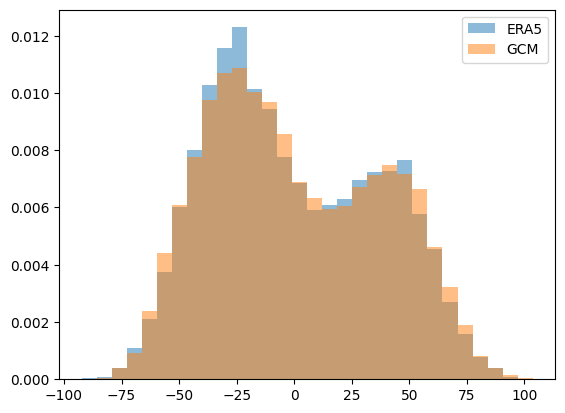

Processing mpi_esm1_2_hr - ssp245


2026-05-20 09:26:51,105 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 28.58 GiB -- Worker memory limit: 36.80 GiB
2026-05-20 09:27:20,832 - PCA - WARNING - Using 4488 out of 65160 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-05-20 09:27:24,416 - PCA - WARNING - Using 4488 out of 65160 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


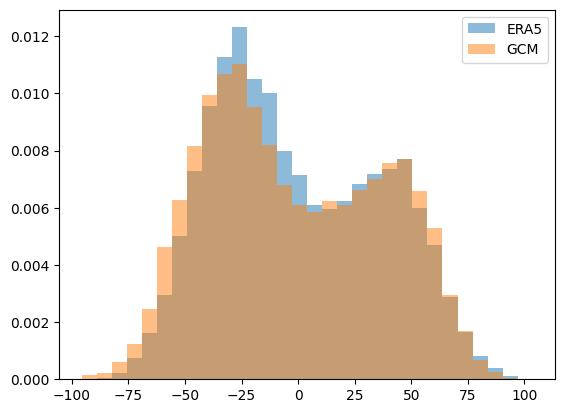

Processing mpi_esm1_2_hr - ssp585


2026-05-20 09:33:41,821 - PCA - WARNING - Using 4488 out of 65160 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-05-20 09:33:47,452 - PCA - WARNING - Using 4488 out of 65160 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


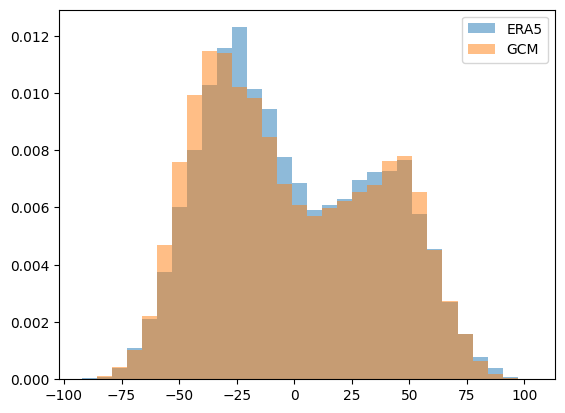

In [8]:
for model in models:
    for ssp in scenarios:
        
        print(f"Processing {model} - {ssp}")

        ds_gcm_mslp = xr.open_dataset(f'outputs/cmip6_models/{model}/{ssp}/mslp_{model}_{ssp}_1deg_bias_corrected.nc')
        ds_gcm_mslp = ds_gcm_mslp.assign_coords(longitude=(ds_gcm_mslp.longitude % 360))
        ds_gcm_mslp = ds_gcm_mslp.sortby("longitude")

        ds_gcm_mslp_estela = get_dynamic_estela_predictor(data=ds_gcm_mslp, estela=estela).isel(time=slice(30,None))

        gcm_pca = pca_ob.transform(ds_gcm_mslp_estela[['mslp', 'mslp_gradient']])

        pcs_gcm = gcm_pca['PCs'].to_dataframe().unstack('n_component')
        pcs_gcm.columns = [f"PC{i+1}" for i in range(pcs_gcm.shape[1])]

        pcs_gcm.to_csv(f'outputs/cmip6_models/{model}/{ssp}/mslp_{model}_{ssp}_pcs_95.csv')

        pc = 0

        x = era5_pcs.iloc[:, pc]
        y = pcs_gcm.iloc[:, pc]

        # Combine data to define common bins
        all_data = np.concatenate([x.values, y.values])

        # Create shared bins
        bins = np.histogram_bin_edges(all_data, bins=30)  # or 'auto'

        # Plot with same bins
        plt.hist(x, bins=bins, density=True, alpha=0.5, label="ERA5")
        plt.hist(y, bins=bins, density=True, alpha=0.5, label="GCM")

        plt.legend()
        plt.show()
